# Car Price Prediction

This project was completed as part of the Oasis Infobyte AICTE Data Science Internship Program.

The objective of this project is to build machine learning models that can predict the selling price of used cars based on features such as present price, car age, kilometers driven, fuel type, seller type, transmission, and previous ownership.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Dataset Overview

The dataset contains information about used cars, including their year, selling price, present price, kilometers driven, fuel type, seller type, transmission, and number of previous owners.

The target variable for this project is `Selling_Price`, which represents the price we want the machine learning models to predict.

In [3]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nFuel Type Distribution:")
print(df["Fuel_Type"].value_counts())

print("\nSeller Type Distribution:")
print(df["Seller_Type"].value_counts())

print("\nTransmission Distribution:")
print(df["Transmission"].value_counts())

Shape:
(301, 9)

Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

Data Types:
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Descriptive Statistics:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000    

### Initial Findings

The dataset contains 301 rows and 9 columns before cleaning. The dataset has no missing values. The categorical variables include fuel type, seller type, and transmission, while the numerical variables include year, selling price, present price, kilometers driven, and owner count.

## 4. Data Cleaning

### Checking for Duplicate Rows

Although the dataset contains no missing values, duplicate rows can still affect the analysis by giving identical records more weight. Therefore, duplicate rows are checked before modeling.

In [4]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [5]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


## 5. Feature Engineering

Feature engineering involves creating a new and potentially more useful feature from existing information.

The `Year` column tells us when a car was manufactured, but car age can be more directly useful for predicting its selling price. Therefore, a new `car_age` feature is created using the year 2026 as the reference year.

In [6]:
df["car_age"] = 2026 - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,car_age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


### Handling `Car_Name` and `Year`

The `Car_Name` column contains 98 unique car names across only 299 records. Encoding all of these categories would create a large number of additional variables relative to the dataset size, so it is excluded from model training.

The `Year` column is also excluded because its information is represented by the newly engineered `car_age` feature.

## 6. Categorical Variable Encoding

Machine learning models require numerical inputs. The categorical variables `Fuel_Type`, `Seller_Type`, and `Transmission` are therefore converted into numerical indicator variables using one-hot encoding.

`drop_first=True` is used to avoid retaining redundant dummy variables.

In [7]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,car_age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,12,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,13,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,9,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,15,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,12,True,False,False,True


df.dtypes

## 7. Preparing Features and Target

The prediction target is `Selling_Price`.

The model features include the numerical variables and the encoded categorical variables. `Car_Name`, `Year`, and `Selling_Price` are excluded from the input features for the reasons discussed above.

In [8]:
model_features = [
    "car_age",
    "Fuel_Type_Diesel",
    "Fuel_Type_Petrol",
    "Seller_Type_Individual",
    "Transmission_Manual",
    "Kms_Driven",
    "Present_Price",
    "Owner"
]

X = df[model_features]
y = df["Selling_Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 8)
y shape: (299,)


## 8. Correlation Analysis

Correlation measures the strength and direction of the linear relationship between numerical variables.

A correlation close to +1 indicates a strong positive relationship, while a correlation close to -1 indicates a strong negative relationship. A value close to 0 indicates little linear relationship.

A correlation heatmap is used to visualize the relationships between the model features and the target variable.

In [9]:
combine_df = pd.concat([X, y], axis=1)

correlation_matrix = combine_df.corr()

print(correlation_matrix)

                         car_age  Fuel_Type_Diesel  Fuel_Type_Petrol  \
car_age                 1.000000         -0.056469          0.052197   
Fuel_Type_Diesel       -0.056469          1.000000         -0.979104   
Fuel_Type_Petrol        0.052197         -0.979104          1.000000   
Seller_Type_Individual  0.036820         -0.345882          0.353865   
Transmission_Manual    -0.003434         -0.086264          0.078700   
Kms_Driven              0.525714          0.173295         -0.173595   
Present_Price           0.053563          0.464849         -0.456746   
Owner                   0.181639         -0.051836          0.054102   
Selling_Price          -0.234369          0.543541         -0.531636   

                        Seller_Type_Individual  Transmission_Manual  \
car_age                               0.036820            -0.003434   
Fuel_Type_Diesel                     -0.345882            -0.086264   
Fuel_Type_Petrol                      0.353865             0.07870

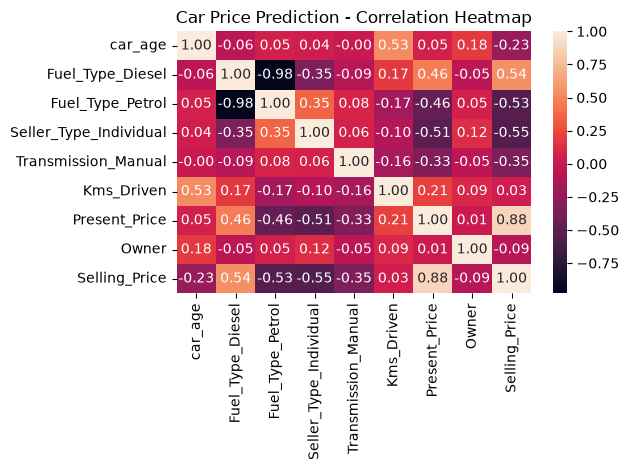

In [10]:
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title("Car Price Prediction - Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Findings

The correlation analysis shows that `Present_Price` has a strong positive relationship with `Selling_Price`, with a correlation of approximately 0.88. This suggests that cars with higher present prices tend to have higher selling prices in this dataset.

Other variables show weaker relationships with the target. Correlation measures linear association and does not by itself establish causation.

## 9. Train-Test Split

The dataset is divided into training and testing sets so that the models can be trained on one portion of the data and evaluated on unseen data.

An 80/20 split is used, with 80% of the observations used for training and 20% used for testing.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (239, 8)
X_test: (60, 8)
y_train: (239,)
y_test: (60,)


## 10. Linear Regression

Linear Regression is a regression algorithm that attempts to model the relationship between the input features and the target variable using a mathematical equation.

It is used as the first model in this project to predict `Selling_Price`.

In [12]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

Price_Prediction = linear_model.predict(X_test)

print("Predicted price:")
print(Price_Prediction)

print("\nActual price:")
print(y_test.values)

Predicted price:
[ 7.50192151  7.79152142  1.36644388  7.00941894 11.16328988  4.53410247
  8.49246345  1.70078181  8.82421963 -0.96348801 10.31444007 -0.97386896
  0.71832735  1.53711566  4.97622203  5.04627395  1.29503012  1.85159301
 21.56570817  0.86767992  0.93078859  2.45202839  5.58169747  0.2581242
  6.26649907  7.82350038  8.68226641  1.1746619   4.84357381  4.92069701
  3.26811058  5.48959967  6.27470319  2.75388094  2.90385159  6.96790194
  1.26406586 -4.97141242  1.38043678 10.38468561  7.10536052  9.04017934
  1.62741133  4.01521109  0.97463542 -2.14675103  8.1451697   4.37395524
  5.64880685 -0.59577608  0.66072164  0.20325682 10.20766115  9.45415687
  7.29949412  6.25536738  3.71408634  3.43110175  9.56341995  9.1600735 ]

Actual price:
[ 8.99  8.35  0.45  7.45  5.25  5.25  5.85  1.15  9.25  0.38  9.65  0.16
  0.25  0.48  4.1   4.5   0.51  1.2  33.    0.6   0.48  1.35  5.25  1.05
  5.5   9.7   8.25  1.1   4.5   4.8   3.25  4.75  5.5   3.    2.65  6.5
  1.11  0.17  1.15  

### Linear Regression Evaluation

The model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

- MAE measures the average absolute difference between predicted and actual values.
- RMSE gives greater weight to larger prediction errors.
- R² measures how well the model explains the variation in the target variable.

In [13]:
linear_mae = mean_absolute_error(y_test, Price_Prediction)
linear_rmse = np.sqrt(mean_squared_error(y_test, Price_Prediction))
linear_r2 = r2_score(y_test, Price_Prediction)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 1.4728924140030137
Linear Regression RMSE: 2.5240350545889743
Linear Regression R²: 0.7528154215844288


## 11. Random Forest Regression

Random Forest Regression is an ensemble learning method that combines multiple decision trees to make predictions.

Unlike Linear Regression, which models the target using a linear relationship, Random Forest can capture more complex patterns in the data.

In [14]:
rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Predicted:")
print(rf_predictions)

print("\nActual:")
print(y_test.values)

Predicted:
[ 9.3872  8.3348  0.4339  6.9225 16.9035  5.2735  6.6136  1.184   8.0396
  0.3157 14.4577  0.213   0.2403  0.459   4.341   5.355   0.6146  1.175
 21.1995  0.5501  0.5457  2.509   6.301   2.327   6.072   8.9422  8.661
  1.1475  4.7691  5.4688  3.408   4.472   6.023   2.7325  3.203   6.5325
  1.1555  0.1488  1.141  16.4166  6.8422  9.0851  0.9173  3.485   0.5669
  0.2089  9.6732  4.905   3.9185  0.2149  0.5757  0.3393 16.8401 10.311
  7.667   6.7105  3.1776  3.6275 10.646   7.342 ]

Actual:
[ 8.99  8.35  0.45  7.45  5.25  5.25  5.85  1.15  9.25  0.38  9.65  0.16
  0.25  0.48  4.1   4.5   0.51  1.2  33.    0.6   0.48  1.35  5.25  1.05
  5.5   9.7   8.25  1.1   4.5   4.8   3.25  4.75  5.5   3.    2.65  6.5
  1.11  0.17  1.15  4.    5.5  12.5   1.05  1.5   0.75  0.12 11.25  4.5
  4.5   0.3   0.55  0.25  2.5  12.9   6.25  4.9   3.75  4.15 11.75  6.95]


### Random Forest Evaluation

In [15]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.4318933333333344
Random Forest RMSE: 3.4208620637201967
Random Forest R²: 0.5459520351711609


## 12. Feature Importance

Random Forest provides feature-importance values that indicate the relative contribution of each input feature to the model's predictions.

A feature-importance chart is used to visualize which variables were most influential when predicting car selling prices.

In [16]:
rf_model.feature_importances_

array([7.21348825e-02, 1.43181942e-03, 1.71396733e-03, 2.80504029e-03,
       5.51310499e-03, 1.33459559e-02, 9.03045760e-01, 9.46998853e-06])

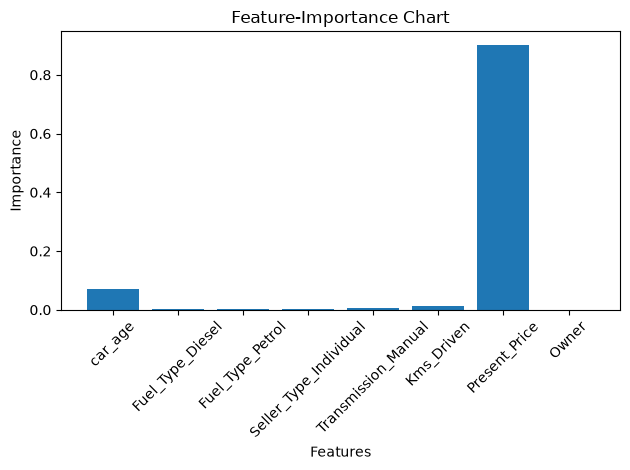

In [17]:
plt.bar(model_features, rf_model.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature-Importance Chart")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance Findings

The feature-importance analysis shows that `Present_Price` is by far the most influential feature in predicting `Selling_Price`, followed by `car_age` and `Kms_Driven`.

This is consistent with the correlation analysis, which also showed a strong positive relationship between `Present_Price` and `Selling_Price`.

## 13. Model Comparison

The two regression models are compared using MAE, RMSE, and R².

For MAE and RMSE, lower values indicate smaller prediction errors. For R², a higher value indicates that the model explains more of the variation in the target variable.

In [18]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R²": [linear_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.472892,2.524035,0.752815
1,Random Forest,1.431893,3.420862,0.545952


### Final Conclusion

Linear Regression performed better than Random Forest on the test set. It achieved a lower MAE and RMSE, indicating smaller prediction errors, and it also achieved a higher R² score. Based on these evaluation metrics, Linear Regression provided a better fit for this dataset and test split.

The feature-importance analysis from Random Forest identified `Present_Price` as the most influential feature for predicting `Selling_Price`, which is consistent with the strong positive correlation observed during the correlation analysis.